In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Dataset medical

1.1. Dataset si DataLoader

In [2]:
# Definim un Dataset custom; pentru tema voastra imaginile pot fi
# fete (face recognition) sau mole-uri (skin lesion classification).
class ImageFolderDataset(Dataset):

    def __init__(self, root_dir, transform):
        # Memoram lista de (cale_imagine, eticheta) pentru a o folosi in __getitem__
        self.samples = []
        self.transform = transform
        df = pd.read_csv(root_dir + ".csv", sep=",")
        df["diagnostic"] = df["diagnostic"].map({"nv": 0, "bcc": 1, "mel": 2, "akiec": 3, "vasc": 4, "bkl": 5, "df": 6})
        for index, row in df.iterrows():
            self.samples.append((os.path.join(root_dir, row["imagine"]), row["diagnostic"]))


    def __len__(self):
        # PyTorch are nevoie sa stie cate exemple sunt in dataset
        return len(self.samples)

    def __getitem__(self, idx):
        # Incarcam imaginea si eticheta pentru indexul cerut
        path, label = self.samples[idx]

        img = Image.open(path).convert("RGB")  # ne asiguram ca avem 3 canale

        if self.transform is not None:
            # Aplicam transformarile (resize, normalizare, augmentari, etc.)
            img = self.transform(img)

        return img, label

In [ ]:
from torchvision import transforms
from torch.utils.data import ConcatDataset, DataLoader
# Transformari minimale: resize la o dimensiune fixa, conversie in tensor si normalizare.
# Pe imaginile de tema (rezolutie mica) folositi o dimensiune apropiata de cea originala.
train_transform = transforms.Compose([
    transforms.Resize((256, 256)), # uniformizam dimensiunea
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=180),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.0 ),
    transforms.GaussianBlur(kernel_size=(3, 3),sigma=(0.1, 2.0)),
    transforms.ToTensor(), # PIL -> Tensor cu valori in [0, 1]
    #transforms.Normalize(mean = [0.7646, 0.5464, 0.5712] , std = [0.1410, 0.1532, 0.1706]), # normalizare simpla in [-1, 1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)), # uniformizam dimensiunea
    transforms.RandomCrop(224),
    transforms.ToTensor(), 
    #transforms.Normalize(mean = [0.7646, 0.5464, 0.5712] , std = [0.1410, 0.1532, 0.1706]),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_set_orig = ImageFolderDataset("vai-de-pielea-mea/train", transform=train_transform)
test_set_orig = ImageFolderDataset("vai-de-pielea-mea/test", transform=train_transform)
train_set = ConcatDataset([train_set_orig, test_set_orig])
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)

test_set_kaggle = ImageFolderDataset("vai-de-pielea-mea/test", transform=val_transform)
test_loader = DataLoader(test_set_kaggle, batch_size=64, shuffle=False, num_workers=2)

def salveaza_vizualizare_augmentare(dataset, transform_augmentare, numele_salvarii="vizualizare_augmentare.png"):
    imagini_clase = {}
    for path, label in dataset.samples:
        if label not in imagini_clase:
            img_pil = Image.open(path).convert("RGB")
            imagini_clase[label] = img_pil
        
        if len(imagini_clase) == 7:
            break

    clase_sortate = sorted(imagini_clase.keys())

    fig, axes = plt.subplots(2, 7, figsize=(20, 6))

    for i, clasa in enumerate(clase_sortate):
        img_originala = imagini_clase[clasa]
        img_before = img_originala.resize((128, 128))
        img_after_tensor = transform_augmentare(img_originala)
        
        img_after = img_after_tensor.permute(1, 2, 0).numpy()
        img_after = (img_after - img_after.min()) / (img_after.max() - img_after.min())

        axes[0, i].imshow(img_before)
        axes[0, i].set_title(f"Clasa {clasa}\nOriginal")
        axes[0, i].axis("off")

        axes[1, i].imshow(img_after)
        axes[1, i].set_title(f"Clasa {clasa}\nAugmentat")
        axes[1, i].axis("off")

    fig.text(0.08, 0.7, "BEFORE", va="center", ha="center", rotation="vertical", fontsize=16, fontweight="bold")
    fig.text(0.08, 0.3, "AFTER", va="center", ha="center", rotation="vertical", fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0.1, 0, 1, 1])
    
    plt.savefig(numele_salvarii, dpi=300)
    plt.show()
    print(f"Graficul comparativ a fost salvat cu succes ca '{numele_salvarii}'!")

salveaza_vizualizare_augmentare(train_set, train_transform, numele_salvarii="medical_before_after_ResNet-18 fara warmup.png")

'\ndef salveaza_vizualizare_augmentare(dataset, transform_augmentare, numele_salvarii="vizualizare_augmentare.png"):\n    imagini_clase = {}\n    for path, label in dataset.samples:\n        if label not in imagini_clase:\n            img_pil = Image.open(path).convert("RGB")\n            imagini_clase[label] = img_pil\n\n        if len(imagini_clase) == 7:\n            break\n\n    clase_sortate = sorted(imagini_clase.keys())\n\n    fig, axes = plt.subplots(2, 7, figsize=(20, 6))\n\n    for i, clasa in enumerate(clase_sortate):\n        img_originala = imagini_clase[clasa]\n        img_before = img_originala.resize((128, 128))\n        img_after_tensor = transform_augmentare(img_originala)\n\n        img_after = img_after_tensor.permute(1, 2, 0).numpy()\n        img_after = (img_after - img_after.min()) / (img_after.max() - img_after.min())\n\n        axes[0, i].imshow(img_before)\n        axes[0, i].set_title(f"Clasa {clasa}\nOriginal")\n        axes[0, i].axis("off")\n\n        axes

1.2. Model, functie de loss, optimizator

In [6]:
import torch.nn as nn
import torch.optim as optim
# Exemplu de MLP simplu pentru imagini 128x128 RGB (3*128*128 = 49152 features de intrare)
class SimpleMLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*128*128, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3), # dropout pentru regularizare
            nn.Linear(512, num_classes), # iesirea = scoruri (logits) per clasa
        )
    def forward(self, x):
        return self.net(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleMLP(num_classes=7).to(device)
# CrossEntropyLoss combina LogSoftmax + NLLLoss; primeste logits, NU probabilitati
criterion = nn.CrossEntropyLoss()
# Adam este o alegere sigura pentru inceput; SGD+momentum poate fi mai bun cu tuning
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

1.3 Bucla de antrenare si evaluare

In [ ]:
import matplotlib.pyplot as plt


def train_one_epoch(model, loader, criterion, optimizer, device):
    # Setăm modelul pe modul "train"
    model.train()

    running_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # 1) Resetăm gradientii
        optimizer.zero_grad()

        # 2) Forward pass
        logits = model(images)

        # 3) Loss
        loss = criterion(logits, labels)

        # 4) Backward pass
        loss.backward()

        # 5) Update parametri
        optimizer.step()

        # Statistici
        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    return running_loss / total, correct / total, f1_macro, f1_micro


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    # Modul eval
    model.eval()

    running_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    return running_loss / total, correct / total, f1_macro, f1_micro


# ---------------------------
# TRAIN LOOP
# ---------------------------

num_epochs = 20

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "train_f1_macro": [], 
    "train_f1_micro": [], 
    "val_f1_macro": [], 
    "val_f1_micro": []
}

for epoch in range(num_epochs):
    tr_loss, tr_acc, tr_f1_macro, tr_f1_micro = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    va_loss, va_acc, va_f1_macro, va_f1_micro = evaluate(
        model, test_loader, criterion, device
    )

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["train_f1_macro"].append(tr_f1_macro)
    history["train_f1_micro"].append(tr_f1_micro)
    history["val_f1_macro"].append(va_f1_macro)
    history["val_f1_micro"].append(va_f1_micro)

    print(
        f"Epoca {epoch+1:02d} | "
        f"train loss={tr_loss:.4f} acc={tr_acc:.3f} f1_mac={tr_f1_macro:.3f} f1_mic={tr_f1_mic:.3f}| "
        f"val loss={va_loss:.4f} acc={va_acc:.3f} f1_mac={va_f1_macro:.3f} f1_mic={va_f1_macro:.3f}"
    )

    # Salvare model (exemplu simplu)
    torch.save(model.state_dict(), "best_model.pt")


Epoca 01 | train loss=5.9891 acc=0.608 f1_mac=0.241 | val loss=1.8642 acc=0.655 f1_mac=0.261
Epoca 02 | train loss=1.5935 acc=0.681 f1_mac=0.324 | val loss=1.5740 acc=0.673 f1_mac=0.260
Epoca 03 | train loss=1.2432 acc=0.701 f1_mac=0.385 | val loss=1.4926 acc=0.660 f1_mac=0.231
Epoca 04 | train loss=1.1312 acc=0.707 f1_mac=0.392 | val loss=1.2285 acc=0.685 f1_mac=0.293
Epoca 05 | train loss=0.9275 acc=0.722 f1_mac=0.440 | val loss=1.4441 acc=0.667 f1_mac=0.294
Epoca 06 | train loss=0.9346 acc=0.724 f1_mac=0.473 | val loss=1.2084 acc=0.673 f1_mac=0.367
Epoca 07 | train loss=0.8163 acc=0.733 f1_mac=0.493 | val loss=1.2578 acc=0.698 f1_mac=0.317
Epoca 08 | train loss=0.8711 acc=0.729 f1_mac=0.485 | val loss=1.2056 acc=0.699 f1_mac=0.319
Epoca 09 | train loss=0.8265 acc=0.742 f1_mac=0.506 | val loss=1.2180 acc=0.670 f1_mac=0.301
Epoca 10 | train loss=0.8189 acc=0.746 f1_mac=0.513 | val loss=1.3255 acc=0.690 f1_mac=0.327
Epoca 11 | train loss=0.9870 acc=0.732 f1_mac=0.486 | val loss=1.6077 

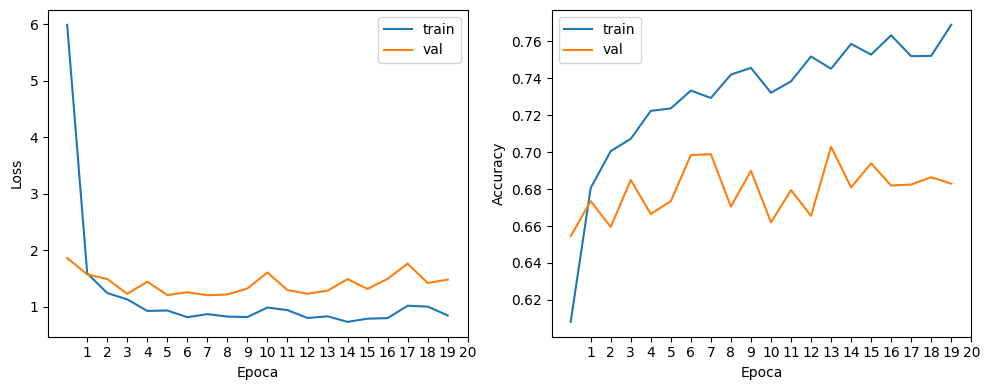

In [ ]:
# ---------------------------
# PLOT RESULTS
# ---------------------------
epochs = list(range(1, num_epochs + 1))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_ylabel("Loss")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_ylabel("Accuracy")
axes[1].set_xlabel("Epoca")
axes[1].legend()
axes[0].set_xticks(epochs)
axes[1].set_xticks(epochs)

plt.tight_layout()
plt.savefig('MLP_simplu_medical_cu dropout.png')
plt.show()

In [ ]:
def plot_confusion_matrix(model, loader, device, num_classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # calculam matricea
    conf_matix = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matix, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.title('Matricea de Confuzie')
    plt.ylabel('Eticheta Reala')
    plt.xlabel('Predictia')
    plt.savefig('MLP_simplu_medical_cu dropout_matrice_confuzie.png')
    plt.show()

plot_confusion_matrix(model, test_loader, device, num_classes=7)

CNN

5.1 Adaugarea BatchNorm intr-un CNN simplu

In [4]:
import torch.nn as nn
# Pattern-ul standard intr-un CNN modern: Conv -> BatchNorm -> Activare -> (eventual Pool)
# IMPORTANT: bias=False la Conv2d cand este urmat de BatchNorm,
# pentru ca BN are deja propriul "beta" care joaca rolul de bias.
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=5, padding=1, bias=False),
            nn.BatchNorm2d(32), # cate un set de (gamma, beta) per canal
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 64x64 -> 32x32
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 32x32 -> 16x16
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            #nn.AdaptiveAvgPool2d(1), # global average pooling -> (B, 128, 1, 1)
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),     
            nn.Linear(28800, 512),     
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1) # (B, 128, 1, 1) -> (B, 128)
        return self.classifier(x)

5.2 Cum se comporta BatchNorm la train vs eval


In [5]:
import torch.optim as optim
import numpy as np
# BatchNorm are DOUA moduri de functionare, controlate de model.train() / model.eval():
#
# - In modul "train": foloseste media si varianta calculate pe BATCH-UL CURENT.
# In paralel, actualizeaza niste statistici "running" (running_mean, running_var)
# printr-o medie mobila exponentiala.
#
# - In modul "eval": foloseste running_mean / running_var (statistici "inghetate"),
# NU statisticile batch-ului curent. Acest lucru este esential pentru ca predictia
# sa fie deterministica si sa nu depinda de ce alte exemple sunt in batch.
#
# Exact din acest motiv este OBLIGATORIU sa apelati model.eval() inainte de validare/inferenta -
# altfel performanta poate parea ciudat de slaba sau de instabila.
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleCNN(num_classes=7).to(device)
labels = np.array([label for _, label in train_set.samples])
class_counts = np.bincount(labels) 
counts = torch.tensor(class_counts, dtype=torch.float)
weights = counts.sum() / (len(counts) * counts)
weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)


5.3 Interactiunea cu dimensiunea batch-ului

In [6]:
# BatchNorm estimeaza media si varianta DIN BATCH. Daca batch-ul este foarte mic
# (ex: batch_size=2 sau batch_size=4), aceste estimari devin zgomotoase si BN
# poate INRAUTATI antrenarea in loc sa o ajute.
#
# Reguli empirice:
# - batch_size >= 32 -> BatchNorm functioneaza foarte bine
# - batch_size < 16 -> luati in considerare alternative: GroupNorm sau LayerNorm
#
# Exemplu de inlocuire BN -> GroupNorm cand suntem fortati la batch-uri mici
# (ex: imagini mari care nu incap in VRAM):
# nn.GroupNorm(num_groups=8, num_channels=64) # 64 canale impartite in 8 grupuri
#
# ATENTIE: BatchNorm necesita batch_size > 1 ca sa poata calcula varianta.
# Daca ultimul batch are dimensiunea 1, antrenarea va da eroare.
# Solutie: drop_last=True in DataLoader.
train_loader = DataLoader(train_set, batch_size=64, shuffle=True,num_workers=2, drop_last=True)

In [ ]:
import matplotlib.pyplot as plt


def train_one_epoch(model, loader, criterion, optimizer, device):
    # Setăm modelul pe modul "train"
    model.train()

    running_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # 1) Resetăm gradientii
        optimizer.zero_grad()

        # 2) Forward pass
        logits = model(images)

        # 3) Loss
        loss = criterion(logits, labels)

        # 4) Backward pass
        loss.backward()

        # 5) Update parametri
        optimizer.step()

        # Statistici
        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    return running_loss / total, correct / total, f1_macro, f1_micro


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    # Modul eval
    model.eval()

    running_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    return running_loss / total, correct / total, f1_macro, f1_micro


# ---------------------------
# TRAIN LOOP
# ---------------------------

num_epochs = 40

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "train_f1_macro": [], 
    "train_f1_micro": [], 
    "val_f1_macro": [], 
    "val_f1_micro": []
}

for epoch in range(num_epochs):
    tr_loss, tr_acc, tr_f1_macro, tr_f1_micro = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    va_loss, va_acc, va_f1_macro, va_f1_micro = evaluate(
        model, test_loader, criterion, device
    )

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["train_f1_macro"].append(tr_f1_macro)
    history["train_f1_micro"].append(tr_f1_micro)
    history["val_f1_macro"].append(va_f1_macro)
    history["val_f1_micro"].append(va_f1_micro)

    print(
        f"Epoca {epoch+1:02d} | "
        f"train loss={tr_loss:.4f} acc={tr_acc:.3f} f1_mic={tr_f1_micro:.3f}  f1_mac={tr_f1_macro:.3f} | "
        f"val loss={va_loss:.4f} acc={va_acc:.3f}  f1_mic={va_f1_micro:.3f} f1_mac={va_f1_macro:.3f}"
    )

    # Salvare model (exemplu simplu)
    torch.save(model.state_dict(), "best_model.pt")
    scheduler.step()


Epoca 01 | train loss=1.7306 acc=0.407 f1_mic=0.407  f1_mac=0.241 | val loss=1.4916 acc=0.454  f1_mic=0.454 f1_mac=0.309
Epoca 02 | train loss=1.3919 acc=0.486 f1_mic=0.486  f1_mac=0.323 | val loss=1.4099 acc=0.444  f1_mic=0.444 f1_mac=0.314
Epoca 03 | train loss=1.3355 acc=0.512 f1_mic=0.512  f1_mac=0.348 | val loss=1.3855 acc=0.508  f1_mic=0.508 f1_mac=0.367
Epoca 04 | train loss=1.2995 acc=0.546 f1_mic=0.546  f1_mac=0.375 | val loss=1.3285 acc=0.490  f1_mic=0.490 f1_mac=0.340
Epoca 05 | train loss=1.2486 acc=0.538 f1_mic=0.538  f1_mac=0.366 | val loss=1.3246 acc=0.511  f1_mic=0.511 f1_mac=0.352
Epoca 06 | train loss=1.2032 acc=0.553 f1_mic=0.553  f1_mac=0.387 | val loss=1.2993 acc=0.611  f1_mic=0.611 f1_mac=0.423
Epoca 07 | train loss=1.2167 acc=0.564 f1_mic=0.564  f1_mac=0.388 | val loss=1.3437 acc=0.563  f1_mic=0.563 f1_mac=0.404
Epoca 08 | train loss=1.1785 acc=0.554 f1_mic=0.554  f1_mac=0.399 | val loss=1.3136 acc=0.569  f1_mic=0.569 f1_mac=0.410
Epoca 09 | train loss=1.1456 acc

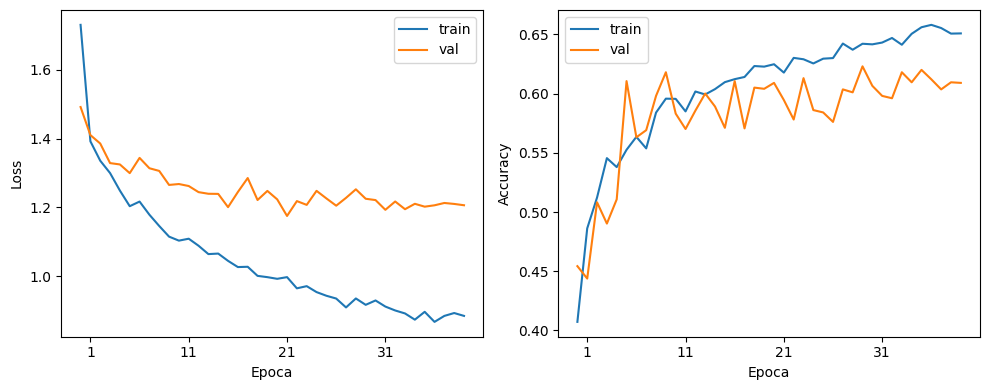

In [14]:
# ---------------------------
# PLOT RESULTS
# ---------------------------
epochs = list(range(1, num_epochs + 1))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_ylabel("Loss")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_ylabel("Accuracy")
axes[1].set_xlabel("Epoca")
axes[1].legend()
axes[0].set_xticks(epochs)
axes[1].set_xticks(epochs)

axes[0].set_xticks(range(1, num_epochs + 1, 10))
axes[1].set_xticks(range(1, num_epochs + 1, 10))

plt.tight_layout()
plt.savefig('CNN_simplu_medical_cu BatchNorm, Dropout, fara adaptiveavgpool cu augmentari toate + Cross Entropy ponderat modif.png')
plt.show()

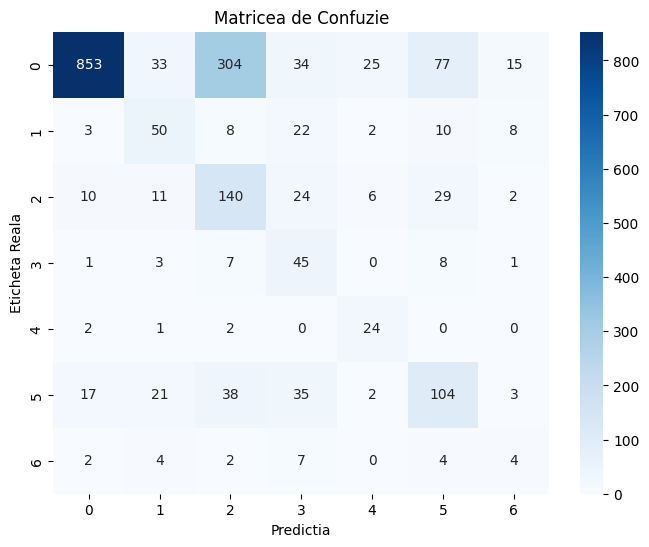

In [15]:
def plot_confusion_matrix(model, loader, device, num_classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # calculam matricea
    conf_matix = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matix, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.title('Matricea de Confuzie')
    plt.ylabel('Eticheta Reala')
    plt.xlabel('Predictia')
    plt.savefig('CNN_simplu_medical_cu BatchNorm, Dropout, fara adaptiveavgpool cu augmentari toate + Cross Entropy ponderat matrice_confuzie modif.png')
    plt.show()

plot_confusion_matrix(model, test_loader, device, num_classes=7)

ResNet-18

In [15]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.layer2.parameters():
    param.requires_grad = True
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True
    
for param in model.layer4.parameters():
    param.requires_grad = True


num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5), 
    nn.Linear(num_ftrs, 7)
)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

parametri = filter(lambda p: p.requires_grad, model.parameters())
labels_train = [label for _, label in train_set_orig.samples]
labels_test  = [label for _, label in test_set_orig.samples]
labels = np.array(labels_train + labels_test)
class_counts = np.bincount(labels) 
counts = torch.tensor(class_counts, dtype=torch.float)
weights = counts.sum() / (len(counts) * counts)
weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(parametri, lr=1e-4, weight_decay=1e-4)
warmup = LinearLR(optimizer, start_factor=0.1, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=35)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

In [16]:
import matplotlib.pyplot as plt


def train_one_epoch(model, loader, criterion, optimizer, device):
    # Setăm modelul pe modul "train"
    model.train()

    running_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # 1) Resetăm gradientii
        optimizer.zero_grad()

        # 2) Forward pass
        logits = model(images)

        # 3) Loss
        loss = criterion(logits, labels)

        # 4) Backward pass
        loss.backward()

        # 5) Update parametri
        optimizer.step()

        # Statistici
        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    return running_loss / total, correct / total, f1_macro, f1_micro


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    # Modul eval
    model.eval()

    running_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    return running_loss / total, correct / total, f1_macro, f1_micro


# ---------------------------
# TRAIN LOOP
# ---------------------------

num_epochs = 40

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "train_f1_macro": [], 
    "train_f1_micro": [], 
    "val_f1_macro": [], 
    "val_f1_micro": []
}

for epoch in range(num_epochs):
    tr_loss, tr_acc, tr_f1_macro, tr_f1_micro = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    va_loss, va_acc, va_f1_macro, va_f1_micro = evaluate(
        model, test_loader, criterion, device
    )

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["train_f1_macro"].append(tr_f1_macro)
    history["train_f1_micro"].append(tr_f1_micro)
    history["val_f1_macro"].append(va_f1_macro)
    history["val_f1_micro"].append(va_f1_micro)

    print(
        f"Epoca {epoch+1:02d} | "
        f"train loss={tr_loss:.4f} acc={tr_acc:.3f} f1_mic={tr_f1_micro:.3f}  f1_mac={tr_f1_macro:.3f} | "
        f"val loss={va_loss:.4f} acc={va_acc:.3f}  f1_mic={va_f1_micro:.3f} f1_mac={va_f1_macro:.3f}"
    )

    # Salvare model (exemplu simplu)
    torch.save(model.state_dict(), "best_model.pt")
    scheduler.step()


Epoca 01 | train loss=2.0797 acc=0.131 f1_mic=0.131  f1_mac=0.110 | val loss=1.6753 acc=0.227  f1_mic=0.227 f1_mac=0.230
Epoca 02 | train loss=1.5129 acc=0.402 f1_mic=0.402  f1_mac=0.270 | val loss=1.1255 acc=0.551  f1_mic=0.551 f1_mac=0.434
Epoca 03 | train loss=1.1399 acc=0.573 f1_mic=0.573  f1_mac=0.417 | val loss=0.8433 acc=0.607  f1_mic=0.607 f1_mac=0.509
Epoca 04 | train loss=0.9978 acc=0.619 f1_mic=0.619  f1_mac=0.467 | val loss=0.7907 acc=0.647  f1_mic=0.647 f1_mac=0.565
Epoca 05 | train loss=0.9205 acc=0.635 f1_mic=0.635  f1_mac=0.504 | val loss=0.7335 acc=0.678  f1_mic=0.678 f1_mac=0.571
Epoca 06 | train loss=0.8671 acc=0.656 f1_mic=0.656  f1_mac=0.523 | val loss=0.7486 acc=0.670  f1_mic=0.670 f1_mac=0.592
Epoca 07 | train loss=0.8005 acc=0.666 f1_mic=0.666  f1_mac=0.548 | val loss=0.6496 acc=0.643  f1_mic=0.643 f1_mac=0.599
Epoca 08 | train loss=0.7612 acc=0.686 f1_mic=0.686  f1_mac=0.574 | val loss=0.5771 acc=0.665  f1_mic=0.665 f1_mac=0.644
Epoca 09 | train loss=0.7302 acc

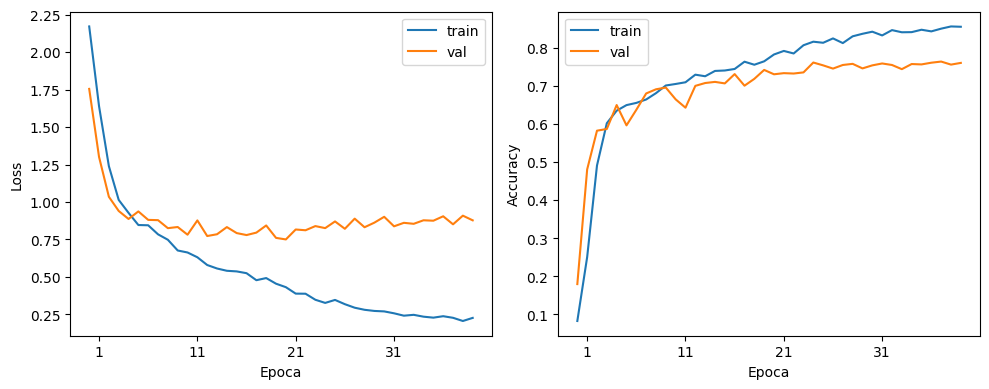

In [6]:
# ---------------------------
# PLOT RESULTS
# ---------------------------
epochs = list(range(1, num_epochs + 1))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_ylabel("Loss")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_ylabel("Accuracy")
axes[1].set_xlabel("Epoca")
axes[1].legend()
axes[0].set_xticks(epochs)
axes[1].set_xticks(epochs)

axes[0].set_xticks(range(1, num_epochs + 1, 10))
axes[1].set_xticks(range(1, num_epochs + 1, 10))

plt.tight_layout()
plt.savefig('medical_ResNet-18 3 layere dezghet cu warmup.png')
plt.show()

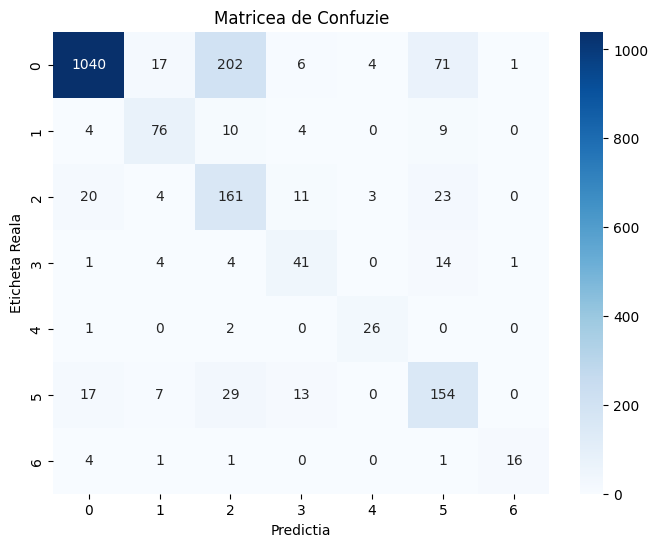

In [7]:
def plot_confusion_matrix(model, loader, device, num_classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # calculam matricea
    conf_matix = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matix, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.title('Matricea de Confuzie')
    plt.ylabel('Eticheta Reala')
    plt.xlabel('Predictia')
    plt.savefig('medical_ResNet-18 cu warmup 3 layere dezghet matrice_confuzie.png')
    plt.show()

plot_confusion_matrix(model, test_loader, device, num_classes=7)

In [17]:
class KaggleDataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.df = pd.read_csv(csv_file)
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Numele coloanei depinde de formatul dat pe Kaggle. Presupunem 'imagine'
        img_name = self.df.iloc[idx]['imagine'] 
        path = os.path.join(self.root_dir, img_name)
        
        img = Image.open(path).convert("RGB")
        
        if self.transform is not None:
            img = self.transform(img)
            
        # Returnam tensorul si numele imaginii (sau id-ul ei) pentru a-l pune in CSV
        return img, img_name

In [18]:
def generate_kaggle_submission_fixed(model, kaggle_loader, device, output_file="submission.csv"):
    model.eval()
    predictions = []
    image_ids = []

    # 1. Cum a învățat modelul tău:
    model_to_text = {0: "nv", 1: "bcc", 2: "mel", 3: "akiec", 4: "vasc", 5: "bkl", 6: "df"}
    
    # 2. Cum așteaptă Kaggle (maparea alfabetică standard):
    text_to_kaggle = {"akiec": 0, "bcc": 1, "bkl": 2, "df": 3, "mel": 4, "nv": 5, "vasc": 6}

    print("Generăm predicțiile corectate pentru Kaggle...")
    with torch.no_grad():
        for images, img_names in kaggle_loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().numpy()
            
            image_ids.extend(img_names)
            
            # REPARARE: Dubla traducere
            for p in preds:
                diagnostic_text = model_to_text[p]          # ex: 0 devine 'nv'
                kaggle_number = text_to_kaggle[diagnostic_text] # 'nv' devine 5
                predictions.append(kaggle_number)           # Salvăm 5 în CSV

    submission_df = pd.DataFrame({
        "Id": image_ids, 
        "Prediction": predictions 
    })
    
    submission_df.to_csv(output_file, index=False)
    print(f"Fișierul {output_file} a fost salvat cu succes!")

# Apelare:
# ACEASTA ESTE CELULA PE CARE TREBUIE SĂ O CORECTEZI
kaggle_set = KaggleDataset(
    root_dir="vai-de-pielea-mea/kaggle_test",  # <-- VERIFICĂ SĂ FIE FOLDERUL DE TEST, nu cel de 'val'
    csv_file="vai-de-pielea-mea/kaggle_test.csv", # <-- VERIFICĂ SĂ FIE CSV-UL DE TEST, nu 'val.csv'
    transform=val_transform 
)

kaggle_loader = DataLoader(kaggle_set, batch_size=64, shuffle=False, num_workers=2)
generate_kaggle_submission_fixed(model, kaggle_loader, device)

Generăm predicțiile corectate pentru Kaggle...
Fișierul submission.csv a fost salvat cu succes!


TensorBoard pentru vizualizarea eficienta

In [32]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import torchvision

# Numele rulei trebuie sa fie descriptiv; recomandare: include arhitectura + hiperparametrii cheie.
# In acest fel, cand deschideti TensorBoard veti putea distinge usor experimentele.
run_name = f"mlp_lr1e-3_bs64_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir=f"runs/{run_name}")

# Imagini: utile pentru a vedea cum arata batch-urile DUPA augmentari.
images, labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
writer.add_image("Train/sample_batch", grid, global_step=0)

# Varianta imbunatatita a buclei de antrenare care logheaza in TensorBoard
for epoch in range(num_epochs):
    tr_loss, tr_acc, tr_f1_macro, tr_f1_micro = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc, va_f1_macro, va_f1_micro = evaluate(model, test_loader, criterion, device)
    
    # Scalars: Logăm și noile metrici F1 dacă vrei să le urmărești
    writer.add_scalar("Loss/train", tr_loss, epoch)
    writer.add_scalar("Loss/val", va_loss, epoch)
    writer.add_scalar("Acc/train", tr_acc, epoch)
    writer.add_scalar("Acc/val", va_acc, epoch)
    writer.add_scalar("F1_Macro/train", tr_f1_macro, epoch)
    writer.add_scalar("F1_Macro/val", va_f1_macro, epoch)

    
    # Logam si learning rate-ul (util cand folositi scheduler)
    writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)
    
    # Histograme: utile pentru a vedea distributia ponderilor sau a gradientilor.
    for name, param in model.named_parameters():
        writer.add_histogram(f"weights/{name}", param, global_step=epoch)
        if param.grad is not None:
            writer.add_histogram(f"grads/{name}", param.grad, global_step=epoch)

# Hiperparametri: tab-ul HPARAMS permite compararea mai multor configuratii.
writer.add_hparams(
    {"lr": 1e-3, "batch_size": 64, "model": "MLP"},
    {"hparam/val_acc": va_acc, "hparam/val_loss": va_loss},
)

# important: inchidem writerul la final ca sa se scrie tot pe disc
writer.close()